In [2]:
import pandas as pd
# Load datasets
fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")

In [3]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true_df.head

<bound method NDFrame.head of                                                    title  \
0      As U.S. budget fight looms, Republicans flip t...   
1      U.S. military to accept transgender recruits o...   
2      Senior U.S. Republican senator: 'Let Mr. Muell...   
3      FBI Russia probe helped by Australian diplomat...   
4      Trump wants Postal Service to charge 'much mor...   
...                                                  ...   
21412  'Fully committed' NATO backs new U.S. approach...   
21413  LexisNexis withdrew two products from Chinese ...   
21414  Minsk cultural hub becomes haven from authorities   
21415  Vatican upbeat on possibility of Pope Francis ...   
21416  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text       subject  \
0      WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1      WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2      WASHINGTON (Reuters)

In [5]:
print("Fake News Dataset Shape:")
print(fake_df.shape)

print("\n")

print("True News Dataset Shape:")
print(true_df.shape)

Fake News Dataset Shape:
(23481, 4)


True News Dataset Shape:
(21417, 4)


In [6]:
print("Fake Dataset Columns")
print(fake_df.columns)

print("\n")

print("True Dataset Columns")
print(true_df.columns)

Fake Dataset Columns
Index(['title', 'text', 'subject', 'date'], dtype='object')


True Dataset Columns
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [7]:
print(fake_df.dtypes)

title      object
text       object
subject    object
date       object
dtype: object


In [8]:
print(true_df.dtypes)

title      object
text       object
subject    object
date       object
dtype: object


In [9]:
print("Missing values in Fake Dataset:")
print(fake_df.isnull().sum())

print("\n")

print("Missing values in True Dataset:")
print(true_df.isnull().sum())

Missing values in Fake Dataset:
title      0
text       0
subject    0
date       0
dtype: int64


Missing values in True Dataset:
title      0
text       0
subject    0
date       0
dtype: int64


In [10]:
print("Duplicate rows in Fake Dataset:", fake_df.duplicated().sum())
print("Duplicate rows in True Dataset:", true_df.duplicated().sum())

Duplicate rows in Fake Dataset: 3
Duplicate rows in True Dataset: 206


In [11]:
print("Sample Dates from Fake Dataset")
display(fake_df["date"].head())

print("\nSample Dates from True Dataset")
display(true_df["date"].head())

Sample Dates from Fake Dataset


0    December 31, 2017
1    December 31, 2017
2    December 30, 2017
3    December 29, 2017
4    December 25, 2017
Name: date, dtype: object


Sample Dates from True Dataset


0    December 31, 2017 
1    December 29, 2017 
2    December 31, 2017 
3    December 30, 2017 
4    December 29, 2017 
Name: date, dtype: object

In [12]:
print("Unique Date Count (Fake):", fake_df["date"].nunique())
print("Unique Date Count (True):", true_df["date"].nunique())

Unique Date Count (Fake): 1681
Unique Date Count (True): 716


In [13]:
fake_df["text_length"] = fake_df["text"].str.len()
true_df["text_length"] = true_df["text"].str.len()

In [14]:
print("Fake News Text Length Statistics")
display(fake_df["text_length"].describe())

print("\nTrue News Text Length Statistics")
display(true_df["text_length"].describe())

Fake News Text Length Statistics


count    23481.000000
mean      2547.396235
std       2532.884399
min          1.000000
25%       1433.000000
50%       2166.000000
75%       3032.000000
max      51794.000000
Name: text_length, dtype: float64


True News Text Length Statistics


count    21417.000000
mean      2383.278517
std       1684.835730
min          1.000000
25%        914.000000
50%       2222.000000
75%       3237.000000
max      29781.000000
Name: text_length, dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

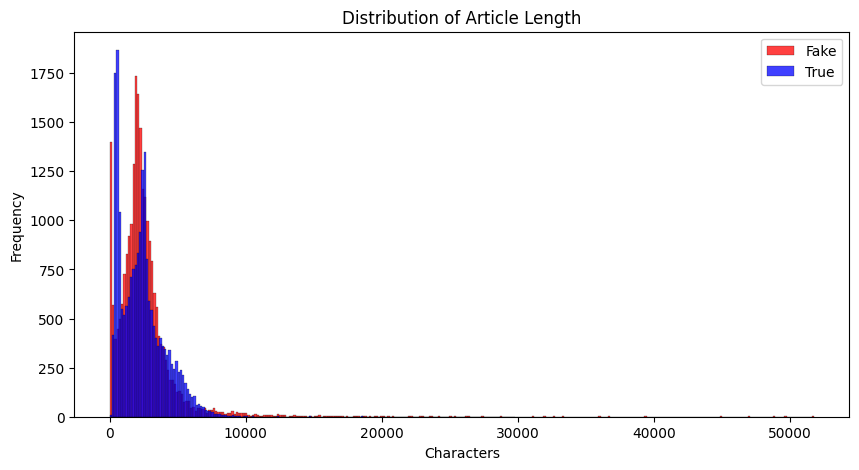

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(fake_df["text_length"], color="red", label="Fake")
sns.histplot(true_df["text_length"], color="blue", label="True")

plt.title("Distribution of Article Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.legend()

plt.show()

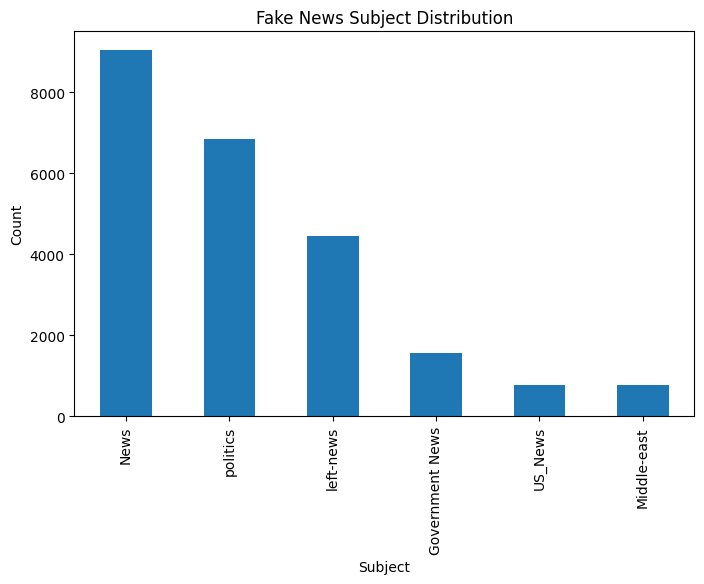

In [17]:
import matplotlib.pyplot as plt

fake_df["subject"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Fake News Subject Distribution"
)

plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

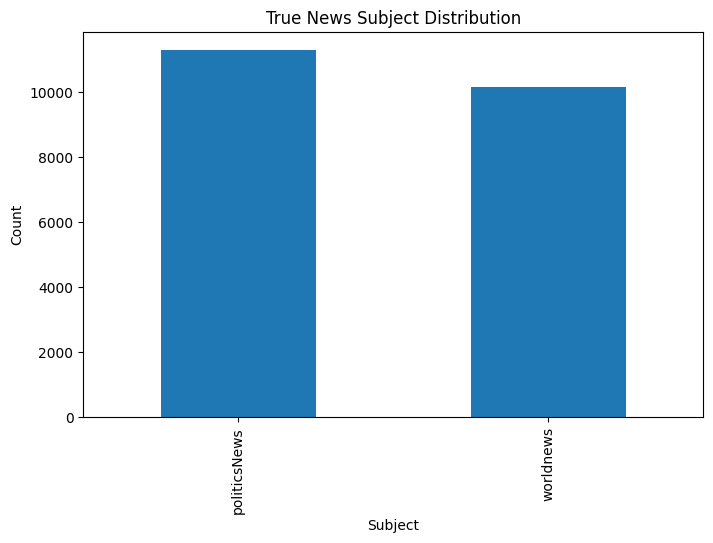

In [20]:
true_df["subject"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="True News Subject Distribution"
)

plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

In [21]:
fake_df["title_length"] = fake_df["title"].str.len()
true_df["title_length"] = true_df["title"].str.len()

In [22]:
print("Average Fake Title Length:", fake_df["title_length"].mean())
print("Average True Title Length:", true_df["title_length"].mean())

Average Fake Title Length: 94.19803245176952
Average True Title Length: 64.667880655554


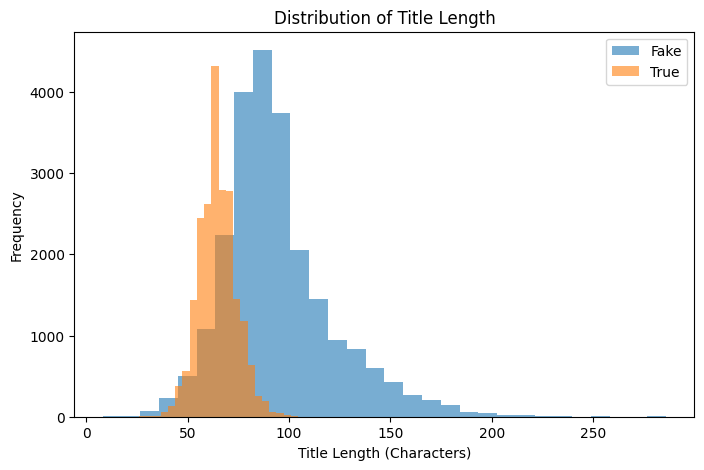

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(fake_df["title_length"], bins=30, alpha=0.6, label="Fake")
plt.hist(true_df["title_length"], bins=30, alpha=0.6, label="True")

plt.title("Distribution of Title Length")
plt.xlabel("Title Length (Characters)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

Final EDA Summary

# Key Findings

- Successfully loaded and explored both datasets.
- No missing values were found.
- Duplicate rows were identified (3 in Fake, 206 in True) and will be removed during preprocessing.
- The datasets are reasonably balanced.
- The `title` and `text` columns contain the primary information for classification.
- The `subject` column may introduce data leakage and will not be used.
- The `date` column is not relevant for fake news classification.
- Article and title lengths vary but are not sufficient as standalone features.
- The dataset is suitable for building both Machine Learning and Deep Learning models.

NLP Techniques

In [1]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

# Load datasets
fake_df = pd.read_csv("../data/fake.csv")
true_df = pd.read_csv("../data/true.csv")

# Create labels
fake_df["label"] = 0
true_df["label"] = 1

# Merge datasets
news_df = pd.concat([fake_df, true_df], ignore_index=True)

# Remove duplicates
news_df = news_df.drop_duplicates()

# Create content column
news_df["content"] = news_df["title"] + " " + news_df["text"]

In [4]:
fake_news = news_df[news_df["label"] == 0]["content"]

true_news = news_df[news_df["label"] == 1]["content"]

In [5]:
fake_text = " ".join(fake_news)

true_text = " ".join(true_news)

In [6]:
fake_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_text)

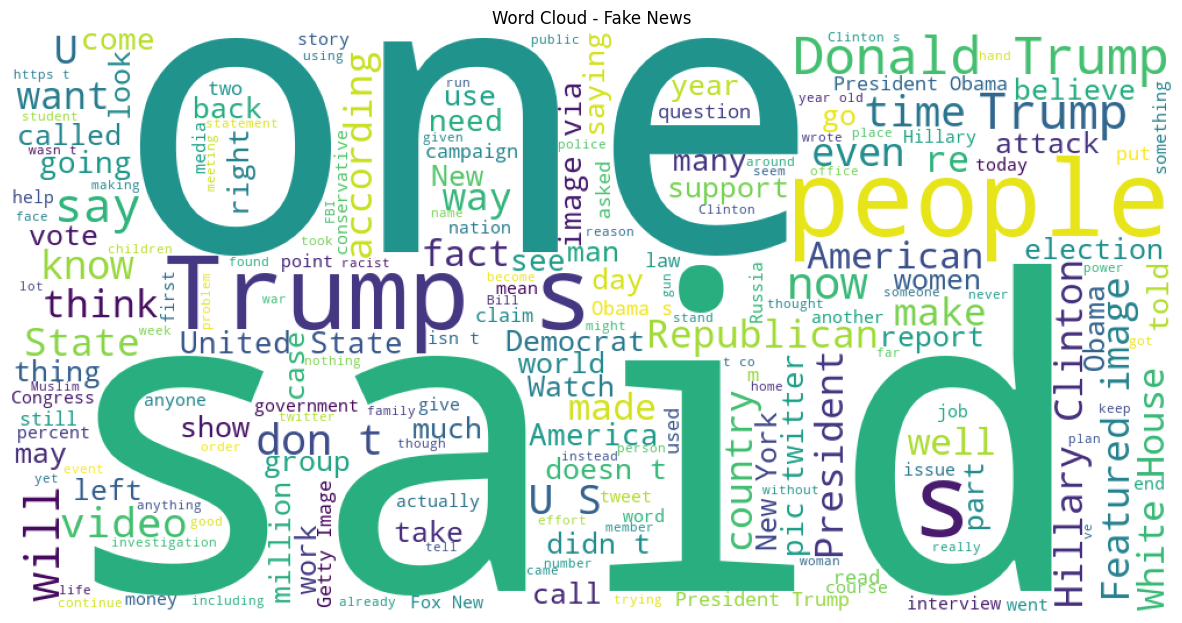

In [7]:
plt.figure(figsize=(15,8))

plt.imshow(fake_wordcloud)

plt.axis("off")

plt.title("Word Cloud - Fake News")

plt.show()

In [8]:
true_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(true_text)

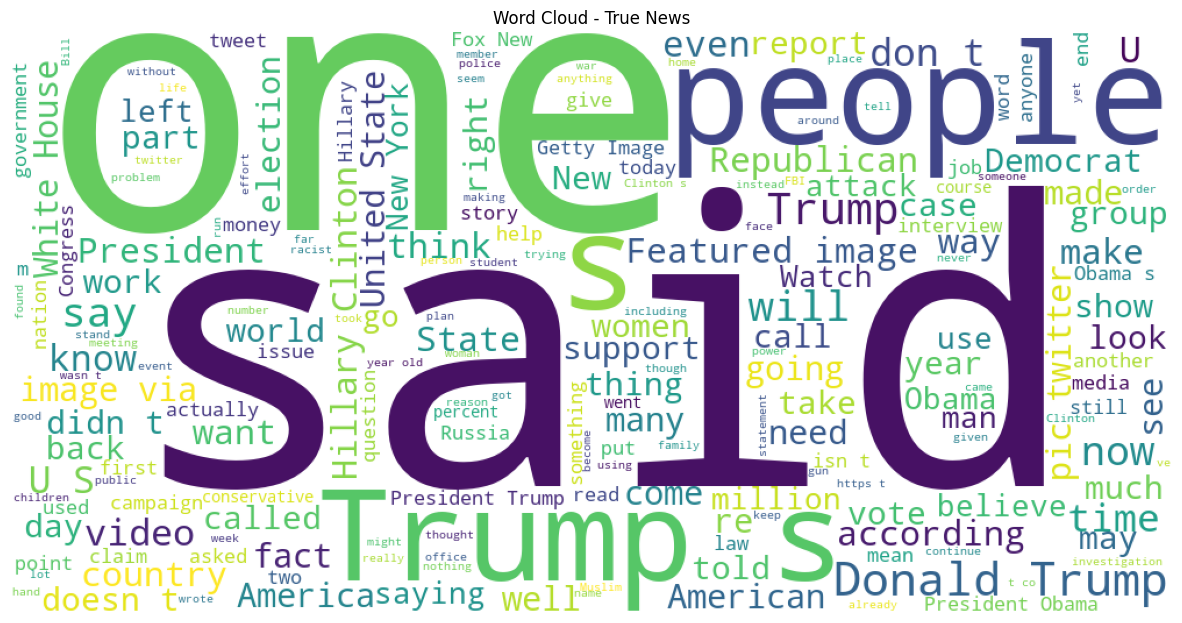

In [9]:
plt.figure(figsize=(15,8))

plt.imshow(true_wordcloud)

plt.axis("off")

plt.title("Word Cloud - True News")

plt.show()